In [ ]:
# Chargement du jeu de données
import os
import pandas as pd
data_path = 'products.csv'
if os.path.exists(data_path):
    df = pd.read_csv(data_path).set_index('Index')
else:
    print('Veuillez placer le fichier products.csv dans le répertoire du projet.')


In [ ]:
df.head()

,Name,Description,Brand,Category,Price,Currency,Stock,EAN,Color,Size,Availability,Internal ID
Index,,,,,,,,,,,,
1,Compact Printer Air Advanced Digital,Situation organization these memory much off.,"Garner, Boyle and Flynn",Books & Stationery,265,USD,774,2091465262179,ForestGreen,Large,pre_order,56
2,Tablet,Discussion loss politics free one thousand.,Mueller Inc,Shoes & Footwear,502,USD,81,5286196620740,Black,8x10 in,in_stock,29
3,Smart Blender Cooker,No situation per.,"Lawson, Keller and Winters",Kitchen Appliances,227,USD,726,1282898648918,SlateGray,XS,in_stock,70
4,Advanced Router Rechargeable,For force gas energy six laugh.,Gallagher and Sons,Kitchen Appliances,121,USD,896,3879177514583,PaleGreen,L,discontinued,31
5,Portable Mouse Monitor Phone,Feeling back religious however author room sci...,Irwin LLC,Kids' Clothing,1,USD,925,9055773261265,SeaShell,100x200 mm,discontinued,10


#Description des variables

*index* : Numéro unique

*Name* : Nom du produit

*Description* : Description du produit

*Brand* : Nom de la marque ou du fabriquant

*Category* : Catégorie du produit

*Price* : Prix du produit

*Currency* : Devise utilisée

*stock* : quantité disponible

*EAN* : Code barresdu produit

*Color* : couleur du produit

*size* : taille du produit

*Availability* : Disponibilité du produit

*Internal ID* : Idifiant interne de gestion

# **Phase d'exploration des données**

In [ ]:
df.shape

(100, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100 entries, 1 to 100
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Name          100 non-null    object
 1   Description   100 non-null    object
 2   Brand         100 non-null    object
 3   Category      100 non-null    object
 4   Price         100 non-null    int64 
 5   Currency      100 non-null    object
 6   Stock         100 non-null    int64 
 7   EAN           100 non-null    int64 
 8   Color         100 non-null    object
 9   Size          100 non-null    object
 10  Availability  100 non-null    object
 11  Internal ID   100 non-null    int64 
dtypes: int64(4), object(8)
memory usage: 10.2+ KB


De la deja on peut detecté que accune variables ne presentent de valeurs manquantes et aussi les differentes types de variables

In [ ]:
df['Brand'].value_counts()

,count
Brand,
"Garner, Boyle and Flynn",1
Mueller Inc,1
"Lawson, Keller and Winters",1
Gallagher and Sons,1
Irwin LLC,1
...,...
Atkinson Inc,1
Shea Ltd,1
West Ltd,1


# **Phase de modelisation des données**

## Variables a modifiées

In [ ]:
df['Size']=df['Size'].astype('category')
df['Availability']=df['Availability'].astype('category')
df['EAN']=df['EAN'].astype('object') #convertie en objet
df['Internal ID']=df['Internal ID'].astype('category')
df['Currency']=df['Currency'].astype('category')
df['Brand']=df['Brand'].astype('category')
df['Category']=df['Category'].astype('category')
df['Color']=df['Color'].astype('category')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100 entries, 1 to 100
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Name          100 non-null    object  
 1   Description   100 non-null    object  
 2   Brand         100 non-null    category
 3   Category      100 non-null    category
 4   Price         100 non-null    int64   
 5   Currency      100 non-null    category
 6   Stock         100 non-null    int64   
 7   EAN           100 non-null    object  
 8   Color         100 non-null    category
 9   Size          100 non-null    category
 10  Availability  100 non-null    category
 11  Internal ID   100 non-null    category
dtypes: category(7), int64(2), object(3)
memory usage: 17.7+ KB


# Statistique descriptive

In [ ]:
df.describe()

,Price,Stock
count,100.00000,100.000000
mean,451.19000,545.710000
std,281.60911,266.716863
min,1.00000,10.000000
25%,230.75000,347.500000
50%,407.50000,575.500000
75%,679.00000,749.250000
max,999.00000,998.000000


La statistique descriptive montre que le prix moyen du produit est environ ` 451$ USD`  et que le stock moyen est de ` 546`  produits.

L'acart du prix au tour de la moyenne: ` 281 $ USD`   montre que les prix sont assez dispersés voir tres hetérogenes cela est aussi noté au niveau du stock ce qui explique un stock max de ` 998 Produits `et un min de ` 10 Produits` et sa peut etre explique differenment selon la periode que l'on a enregsistré le dataset a savoir si c'est juste apres stockage ou des jours apres .

Le produit le plus chere vaut ` 999 $ USD` tandisque le moins cher coute ` 1$ USD` .
Une petite intuition peut surgir a ce niveau,peut etre dans le magazin il y'a des produits minimalistes comme des coques de telephones qui peuvent couter ` 1$ USD` et d'autre comme les materiaux Automatisés qui sont assez cheres et peuvent valoir jusqu'a  ` 999 $ USD`

---
Ici aussi on note qu'une moitié  des produits coute ` 408 $ USD`  ou moins et l'autre moitié vaut plus que cette valeure.

75% des produits sont vendus a `679 $ USD` Ou moins et seulement 25% coutent plus de `679 $ USD`

Aussi seulement 25% coutent au plus `230 $ USD` .


---
25% du stock compte ` 347 produits` ou moins ,et les 50% en comptent  plus` 576 Produits ` alors le stok est bon la majeur partie des produit sont bien representé c'est du a un ecoulement lent ou un debut de restockage ,en fin on a que 75% du stock compte ` 749 priduits` ou moins




# Statiqtique descriptive des variables categorielles

In [ ]:
df.describe(include='category')

,Brand,Category,Currency,Color,Size,Availability,Internal ID
count,100,100,100,100,100,100,100
unique,100,32,1,72,17,6,66
top,Ali-Oliver,Automotive,USD,Cyan,L,pre_order,88
freq,1,6,100,4,10,25,4


Les stat descriptives des vars categorielles montrent que le magazin possede 100 founisseurs dont le plus frequent demeure Ali-Oliver,la category Automative est  AUSSI plus representative dans le magazin avec 6 occurences.

La money principal de l'entreprise demeure le Dollars USD.

La couleure Cyan est majoritaire et la taille L aussi est tres presentée,la plus part des produits sont aussi en precommande et l'identifiant du produit majoritaire est 88


# Valeurs manquantes

In [ ]:
df.isnull().sum()

,0
Name,0
Description,0
Brand,0
Category,0
Price,0
Currency,0
Stock,0
EAN,0
Color,0
Size,0


In [ ]:
df.duplicated().sum()

np.int64(0)

# **Visualisation des données**

## Analyse univariée

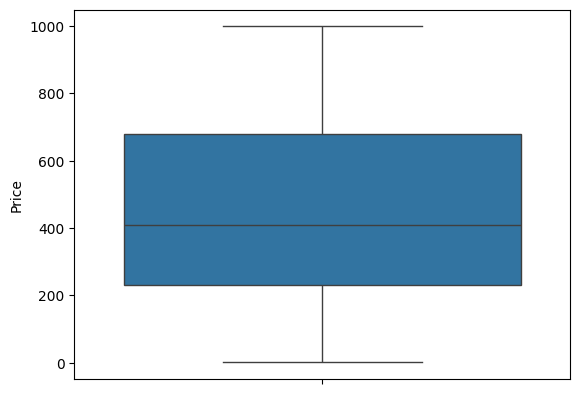

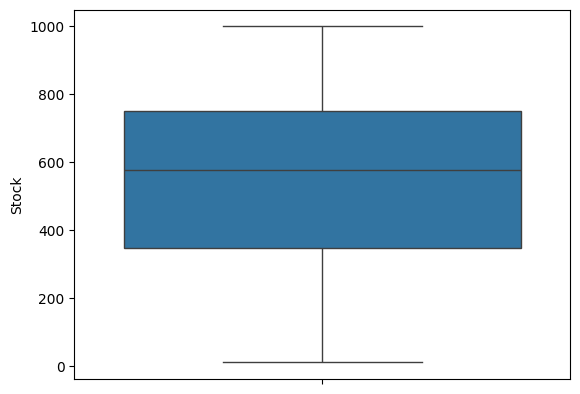

In [ ]:
col=df.select_dtypes('int').columns
for i in col:
    plt.figure()
    sns.boxplot(df[i])

Nous remarquons dans notre dataset qu'il y'a pas de valeures manquantes,pas de valeures dubliquées ni de valeures aberantes

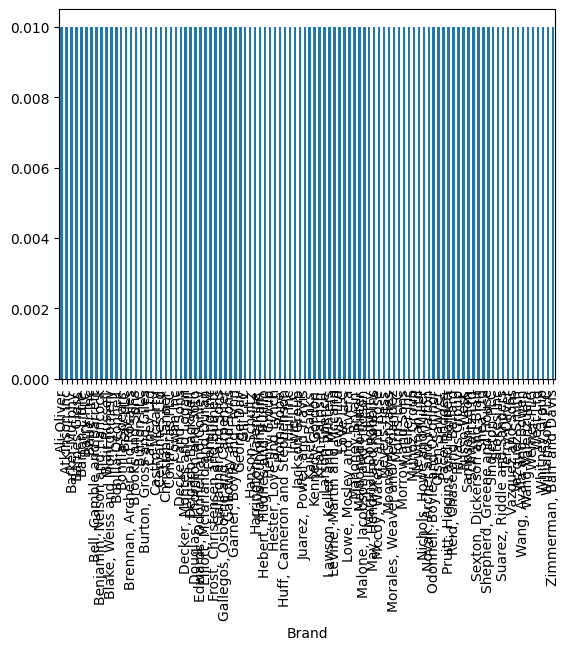

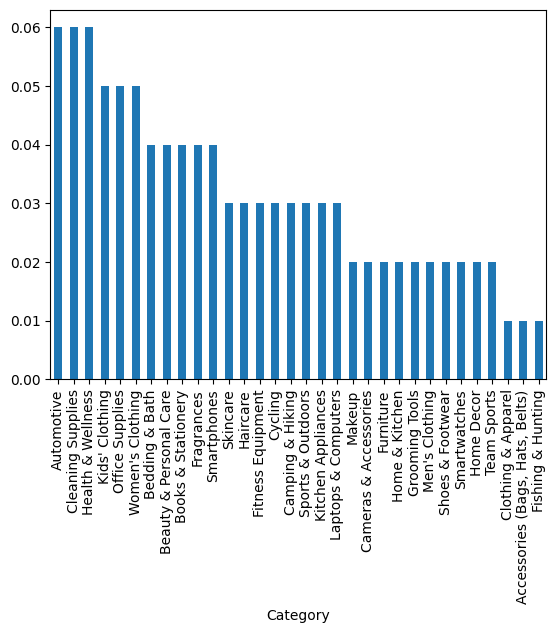

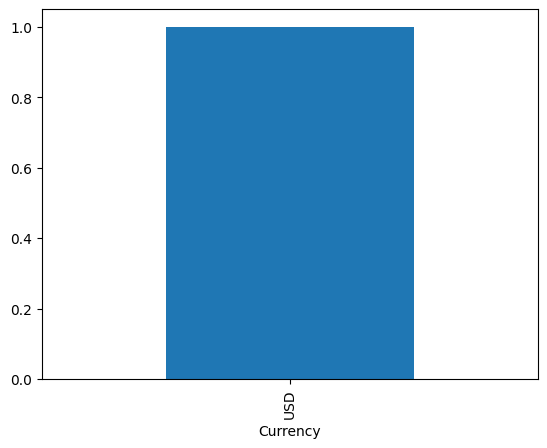

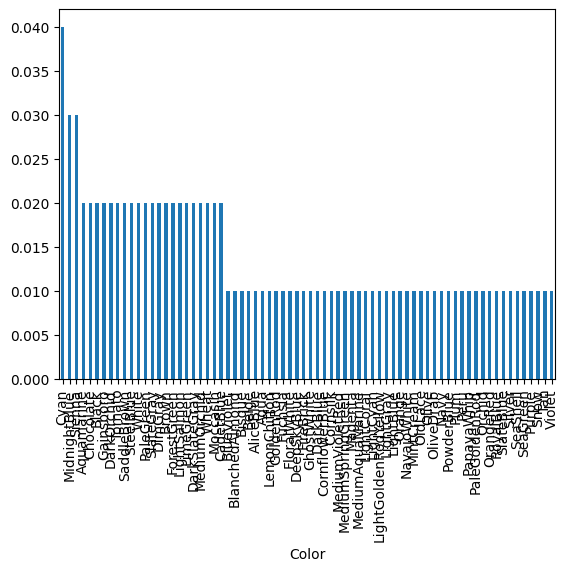

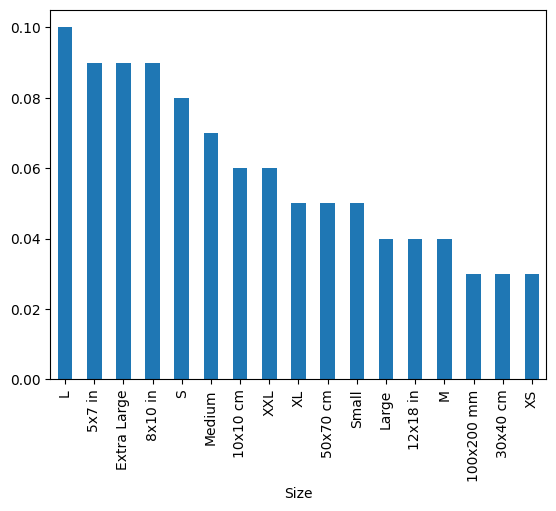

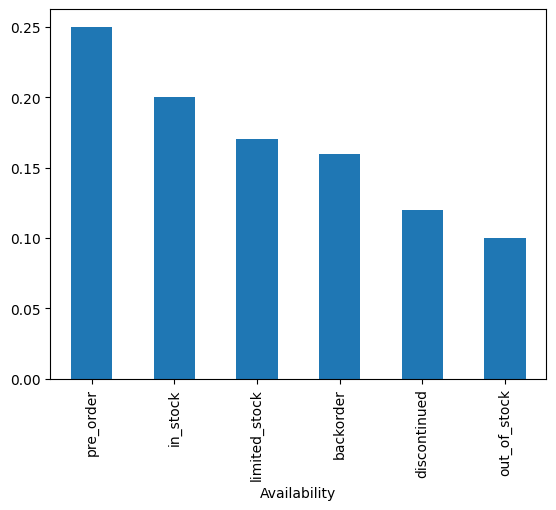

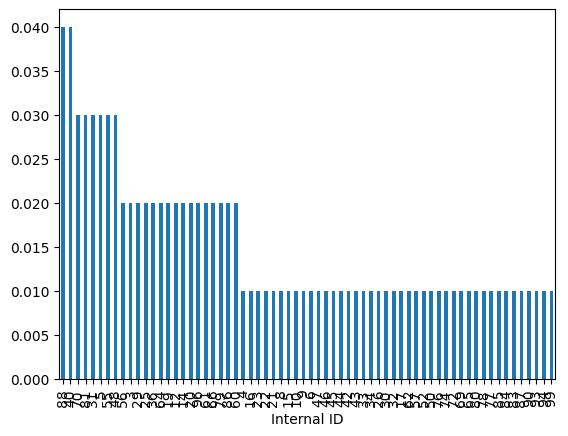

In [ ]:
coll=df.select_dtypes('category').columns
for i in coll:
    plt.figure()
    df[i].value_counts(normalize=True).plot.bar()  ### graphique en bar
    plt.show()

D'apres ces représentations graphique les 6 produit les plus majoritaire sont Automative,clining supplies,Health & wellness,kid's clothing,et office supplies
par contre les produits minoritaires sont fishing & hunting et les accessoire comme les sac,les chapeaux...

Tout en haut on avais remarqué que la taille la plus grande est le L et la plus petit  xs

# Analyse Bivariée

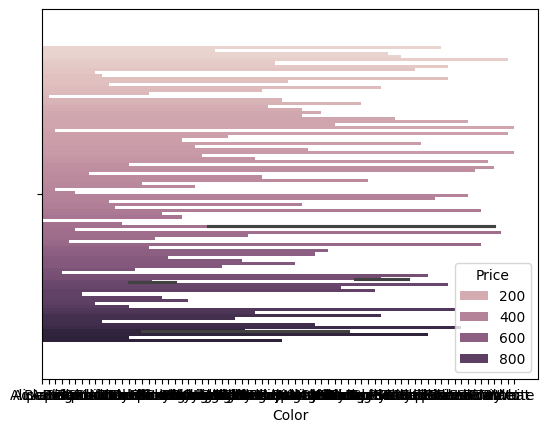

In [ ]:

    sns.barplot( x=df['Color'],hue=df['Price']) ### graphique en bar
    plt.show()

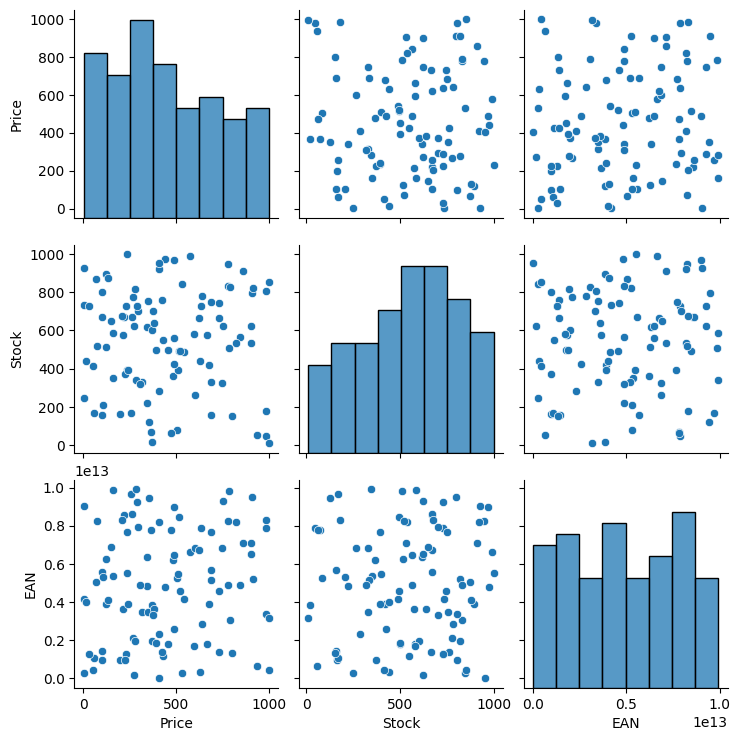

In [ ]:
sns.pairplot(df)

Ici on a essayé de visualiser le stock et le prix par la fonction paireplot mais les graphs ne sont pas trop parlantent alors on vas essayé avec les boxplots

/tmp/ipython-input-2567078632.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


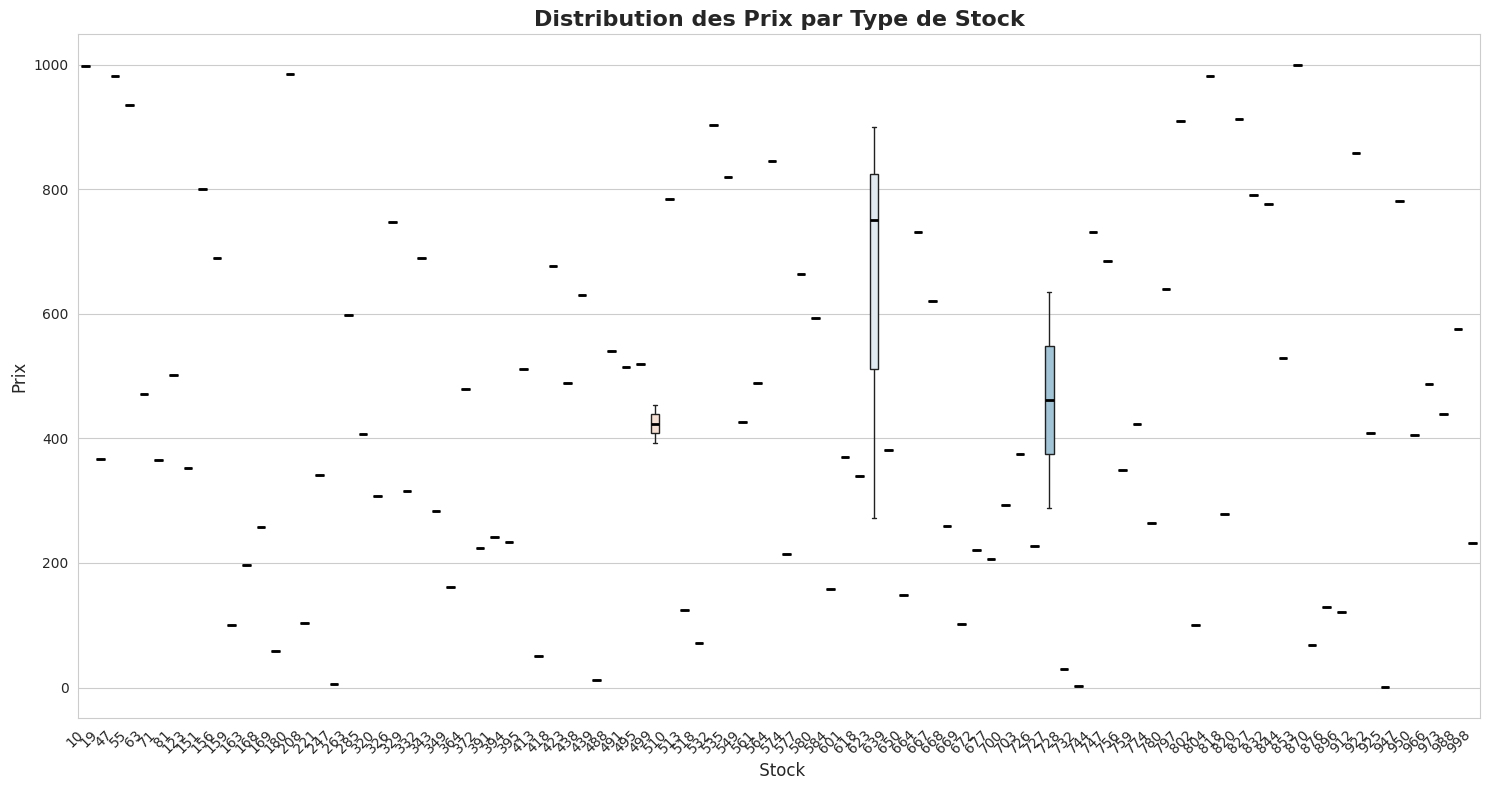

In [ ]:

# 1. Appliquer un style Seaborn agréable (optionnel)
sns.set_style("whitegrid")

# 2. Initialiser la figure avec une taille appropriée pour de nombreuses catégories
#    Largeur adaptée pour les étiquettes, hauteur standard
plt.figure(figsize=(15, 8))

# 3. Tracer le boxplot principal avec des ajustements visuels
sns.boxplot(
    x='Stock',
    y='Price',
    data=df,
    width=0.6,          # Réduit légèrement la largeur des boîtes
    palette="RdBu",    # Change la palette de couleurs
    medianprops={'color': 'black', 'linewidth': 2} # Met en évidence la médiane
)

# 4. Améliorer la lisibilité de l'axe X (obligatoire si condensé)
plt.xticks(
    rotation=45,        # Pivote les étiquettes de 45 degrés
    ha='right',         # Alignement horizontal pour mieux coller à la graduation
    fontsize=10         # Ajuste la taille de la police
)

# 5. Ajouter des titres clairs
plt.title("Distribution des Prix par Type de Stock", fontsize=16, fontweight='bold')
plt.xlabel(" Stock", fontsize=12)
plt.ylabel("Prix", fontsize=12)
# 6. Assurer que tout le texte rentre dans la figure
plt.tight_layout()
plt.show()


# Analyse
>Nous remarquons ici  par les boxplots les plus visibles que les produits qui ont un prix max de  650 ont 728 produits en stock et ceux qui valent 900 comptent 623 produis stockés,par contre les produits dont le prix maximal est au environt de 450 $ n'ont que 510 produit stockés


---



#Analyse
Les boxplots permettent d’observer la distribution des stocks selon différentes gammes de prix. On remarque que certains produits appartenant à des tranches de prix plus élevées présentent des niveaux de stock importants (par exemple autour de 700 unités). À l’inverse, des gammes de prix plus modérées présentent parfois des stocks plus faibles.

#Interprétation
Cette observation ne permet pas de conclure que les produits plus chers sont plus demandés ou moins demandés.
Elle indique simplement que, dans ce dataset, certaines gammes de prix élevées sont associées à des niveaux de stock importants.
Cela peut être dû :

➤à une stratégie d'approvisionnement,

➤à une sur-anticipation de la demande,

➤ou simplement à une absence de ventes pour ces articles.

Sans données de ventes ni dates de stock, il est impossible d’interpréter la demande réelle.
On peut uniquement décrire la relation entre prix et quantité disponible au moment du relevé.

/tmp/ipython-input-1430829098.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


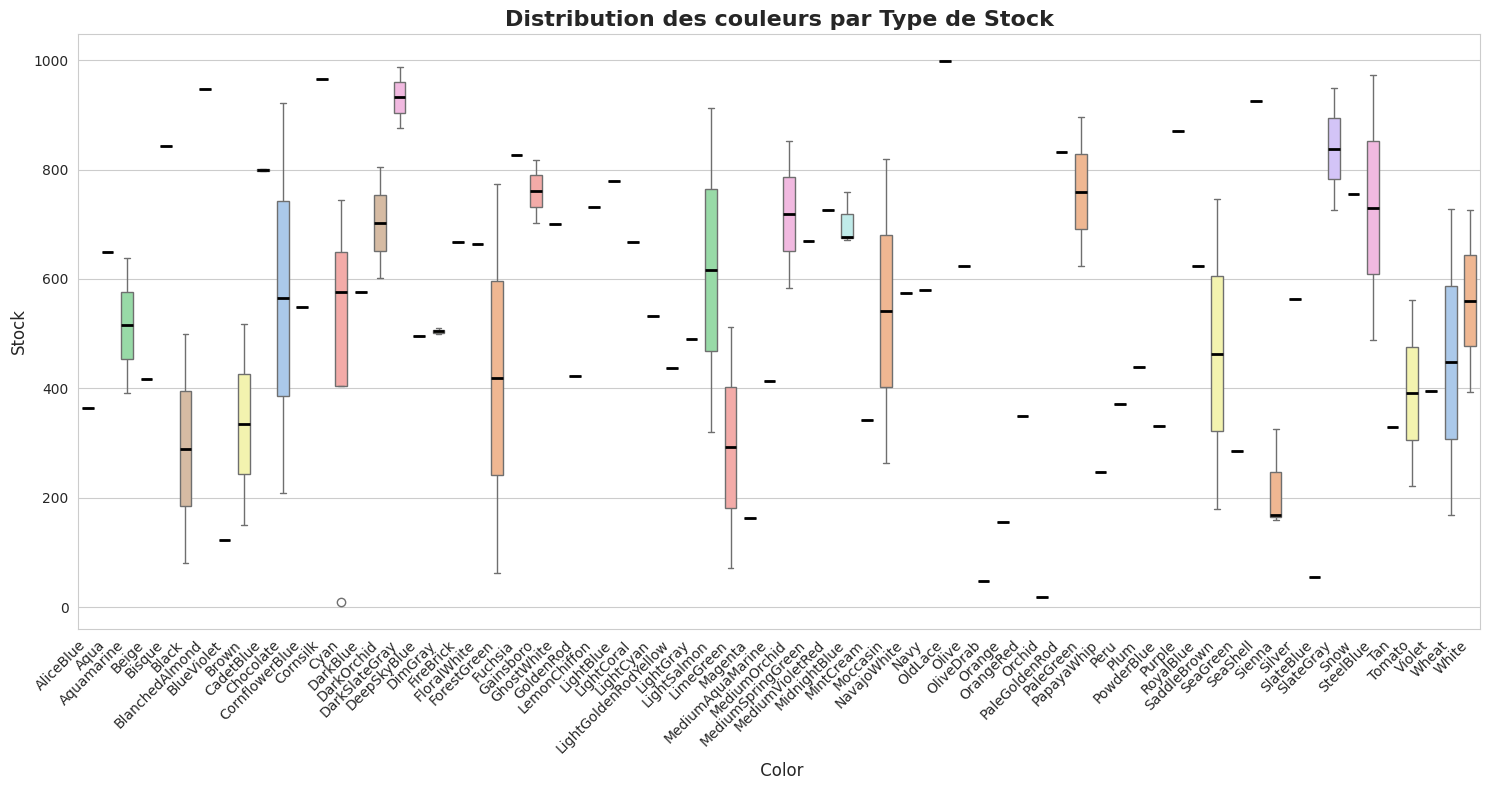

In [ ]:

# 1. Appliquer un style Seaborn agréable (optionnel)
sns.set_style("whitegrid")

# 2. Initialiser la figure avec une taille appropriée pour de nombreuses catégories
#    Largeur adaptée pour les étiquettes, hauteur standard
plt.figure(figsize=(15, 8))

# 3. Tracer le boxplot principal avec des ajustements visuels
sns.boxplot(
    x='Color',
    y='Stock',
    data=df,
    width=0.6,          # Réduit légèrement la largeur des boîtes
    palette="pastel",    # Change la palette de couleurs
    medianprops={'color': 'black', 'linewidth': 2} # Met en évidence la médiane
)

# 4. Améliorer la lisibilité de l'axe X (obligatoire si condensé)
plt.xticks(
    rotation=45,        # Pivote les étiquettes de 45 degrés
    ha='right',         # Alignement horizontal pour mieux coller à la graduation
    fontsize=10         # Ajuste la taille de la police
)

# 5. Ajouter des titres clairs
plt.title("Distribution des couleurs par Type de Stock", fontsize=16, fontweight='bold')
plt.xlabel(" Color", fontsize=12)
plt.ylabel("Stock", fontsize=12)
# 6. Assurer que tout le texte rentre dans la figure
plt.tight_layout()
plt.show()


# Analyse
>Ici on peut remarqué que la couleure` deepskyblue`   , `Tan` et  `snow` presentents des niveaux de stock plus elevés
par contre les couleurs comme `silver` , `blanchedAlmond` et `Magenta` presentent  des niveauix de stock moins importants
---
#Interpretation

>Ces différences n’indiquent pas une demande plus forte ou plus faible selon la couleur, car le dataset ne contient ni ventes ni dates de stock.
Elles montrent simplement que, pour ce relevé de données, certaines couleurs sont disponibles en quantités plus importantes que d'autres.
Cela peut refléter :

➤une stratégie d’approvisionnement,

➤la popularité supposée des couleurs,

➤ou un stock non encore écoulé.

/tmp/ipython-input-3899727186.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


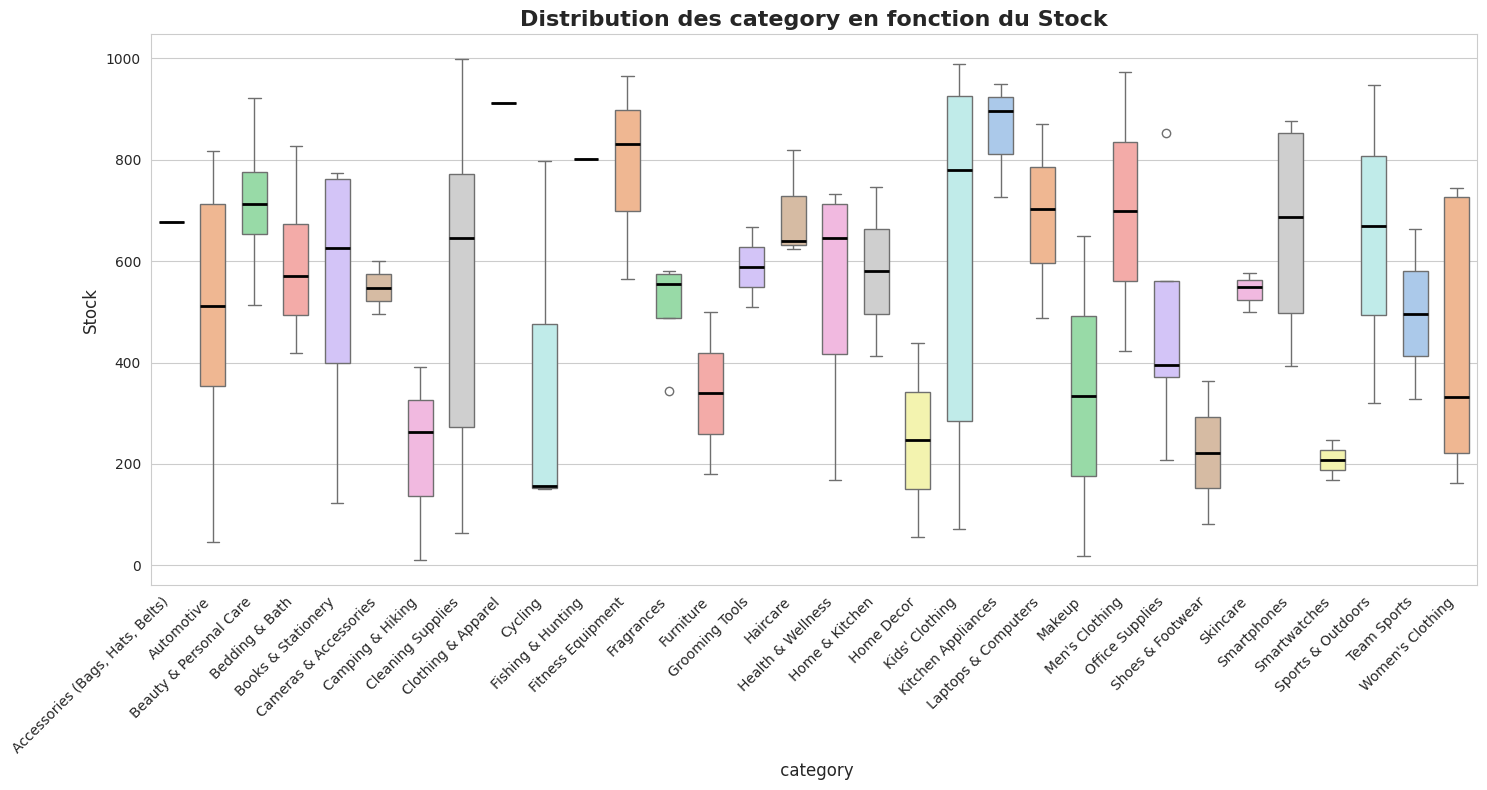

In [ ]:

# 1. Appliquer un style Seaborn agréable (optionnel)
sns.set_style("whitegrid")

# 2. Initialiser la figure avec une taille appropriée pour de nombreuses catégories
#    Largeur adaptée pour les étiquettes, hauteur standard
plt.figure(figsize=(15, 8))

# 3. Tracer le boxplot principal avec des ajustements visuels
sns.boxplot(
    x='Category',
    y='Stock',
    data=df,
    width=0.6,          # Réduit légèrement la largeur des boîtes
    palette="pastel",    # Change la palette de couleurs
    medianprops={'color': 'black', 'linewidth': 2} # Met en évidence la médiane
)

# 4. Améliorer la lisibilité de l'axe X (obligatoire si condensé)
plt.xticks(
    rotation=45,        # Pivote les étiquettes de 45 degrés
    ha='right',         # Alignement horizontal pour mieux coller à la graduation
    fontsize=10         # Ajuste la taille de la police
)

# 5. Ajouter des titres clairs
plt.title("Distribution des category en fonction du Stock", fontsize=16, fontweight='bold')
plt.xlabel(" category", fontsize=12)
plt.ylabel("Stock", fontsize=12)
# 6. Assurer que tout le texte rentre dans la figure
plt.tight_layout()
plt.show()


# Analyse
>la category Cleaning supplies, kid's clothing,et men's clothing presentent des niveau de stock plus importants,alors que Smartwatches,home decor et Shoes & Footwear presentent des niveau de stock assez faible
# Interpretation
>Cette observation est purement descriptive et  ne peut pas  conclure que Cleaning supplies est plus demandé ,ou que Shoes & Footwear est moins vendu.
Elle indique simplement qu’au moment du relevé, certaines catégories étaient plus ou moins présentes dans le stock.
cette forte présence des catégories comme  Cleaning supplies, kid's clothing,et men's clothing  peuvent etre une strategie de l'entreprise qui decide d'en stocker suffisamment pour éviter une rupture de stock ,il se pourrait aussi que ces catégories sont plus demandées ,oubien aussi que leurs stocks n'est pas encore écoulé  
Pour les catégories comme Smartwatches,home decor et Shoes & Footwear ,leurs niveau de stock moins important peut etre du a une stratégie marketing ,au fait qu’elles sont moins demandées par rapport aux autres catégories ,ou bien que leurs stocks était  deja écoulé au moment du relevé

/tmp/ipython-input-330428677.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


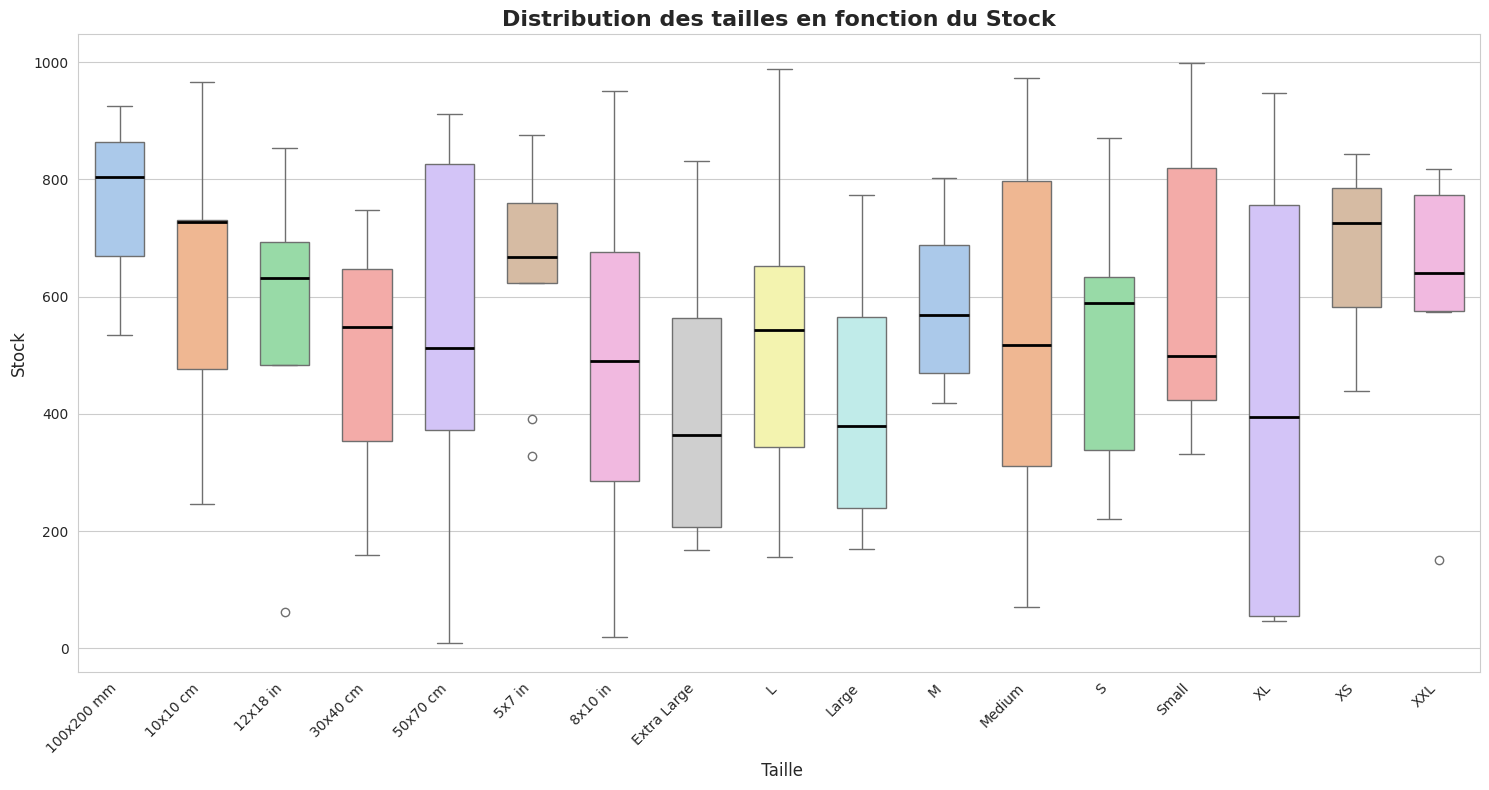

In [ ]:

# 1. Appliquer un style Seaborn agréable (optionnel)
sns.set_style("whitegrid")

# 2. Initialiser la figure avec une taille appropriée pour de nombreuses catégories
#    Largeur adaptée pour les étiquettes, hauteur standard
plt.figure(figsize=(15, 8))

# 3. Tracer le boxplot principal avec des ajustements visuels
sns.boxplot(
    x='Size',
    y='Stock',
    data=df,
    width=0.6,          # Réduit légèrement la largeur des boîtes
    palette="pastel",    # Change la palette de couleurs
    medianprops={'color': 'black', 'linewidth': 2} # Met en évidence la médiane
)

# 4. Améliorer la lisibilité de l'axe X (obligatoire si condensé)
plt.xticks(
    rotation=45,        # Pivote les étiquettes de 45 degrés
    ha='right',         # Alignement horizontal pour mieux coller à la graduation
    fontsize=10         # Ajuste la taille de la police
)

# 5. Ajouter des titres clairs
plt.title("Distribution des tailles en fonction du Stock", fontsize=16, fontweight='bold')
plt.xlabel(" Taille", fontsize=12)
plt.ylabel("Stock", fontsize=12)
# 6. Assurer que tout le texte rentre dans la figure
plt.tight_layout()
plt.show()


# Analyse
>la taille XL,L,S ,médium ,10x10cm,8x10 in, presentent un niveau de stock plus elevé tandisque les tailles xxl,xs,M,large,30X40cm, presentent un niveau de stock moins important
# Interpretation
>Pour les vêtements les tailles xl,l,s sont peut être plus vendu ce qui ne peut pas etre confirmé vue qu’on a pas les données de ventes dans ce dataset,peut etre aussi cette leurs stock n’était pas encore écoulé ou bien que le magazin décide dans stocker plus pour des raisons marketing .
Cette interprétation est aussi valable pour les autres tailles comme médium ,10x10cm et 8x10in

>Pour les catégories avec un niveau de stock moins élevé comme xxl,xs,M pour les vêtements et large,et 30X40cm pour les autre ,en attendant d'avoir une confirmation par les données de ventes on peut supposer que ces catégories sont peut etre moins vendus ou bien que leurs stocks étaient deja épuisés au moment de l’enregistrement du dataset

/tmp/ipython-input-3818636293.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


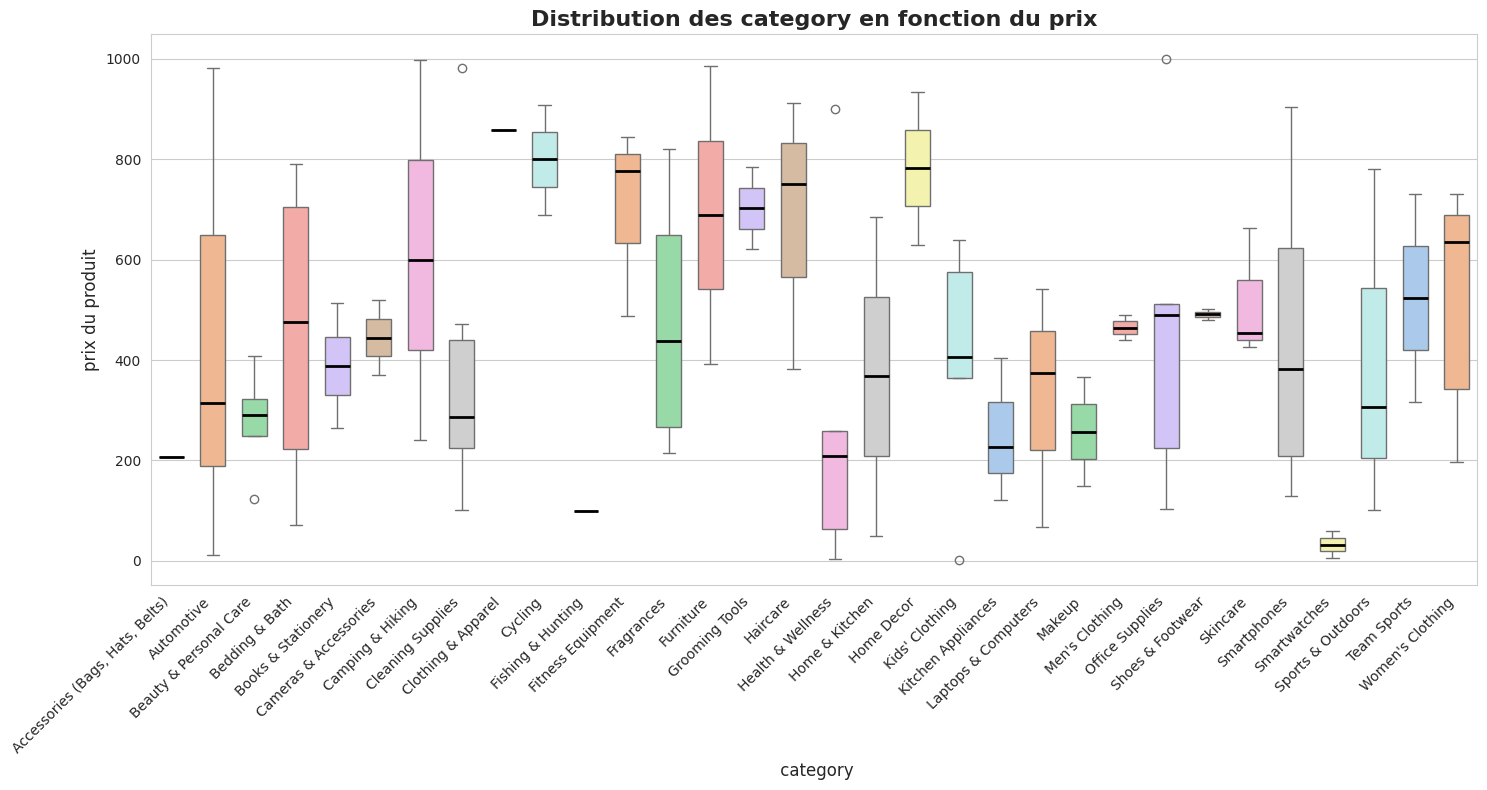

In [ ]:

# 1. Appliquer un style Seaborn agréable (optionnel)
sns.set_style("whitegrid")

# 3. Tracer le boxplot principal avec des ajustements visuels
sns.boxplot(
    x='Category',
    y='Price',
    data=df,
    width=0.6,          # Réduit légèrement la largeur des boîtes
    palette="pastel",    # Change la palette de couleurs
    medianprops={'color': 'black', 'linewidth': 2} # Met en évidence la médiane
)

# 4. Améliorer la lisibilité de l'axe X (obligatoire si condensé)
plt.xticks(
    rotation=45,        # Pivote les étiquettes de 45 degrés
    ha='right',         # Alignement horizontal pour mieux coller à la graduation
    fontsize=10         # Ajuste la taille de la police
)

# 5. Ajouter des titres clairs
plt.title("Distribution des category en fonction du prix", fontsize=16, fontweight='bold')
plt.xlabel(" category", fontsize=12)
plt.ylabel("prix du produit", fontsize=12)
# 6. Assurer que tout le texte rentre dans la figure
plt.tight_layout()
plt.show()


# Analyse  
 >catégories comme camping et hiking,furniture,et Automative presentent un niveau  de prix plus élevé   ,par contre celles comme smartwatches,health and wellness,et makeup présentent des niveaux de prix  moins cheres

#Interprétation  
> Les catégories comme camping and hiking,furniture,et Automative couent relativement tres cheres 1000 $ ou presque .
Celle  qui  valent  moins cheres sont smartwatches dont le prix max vaut moins de 1000 dollars  ,puis de health and wellness,et makeup dont leurs prix max vaut respectivement 230  et 380 dollars

/tmp/ipython-input-1578761504.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


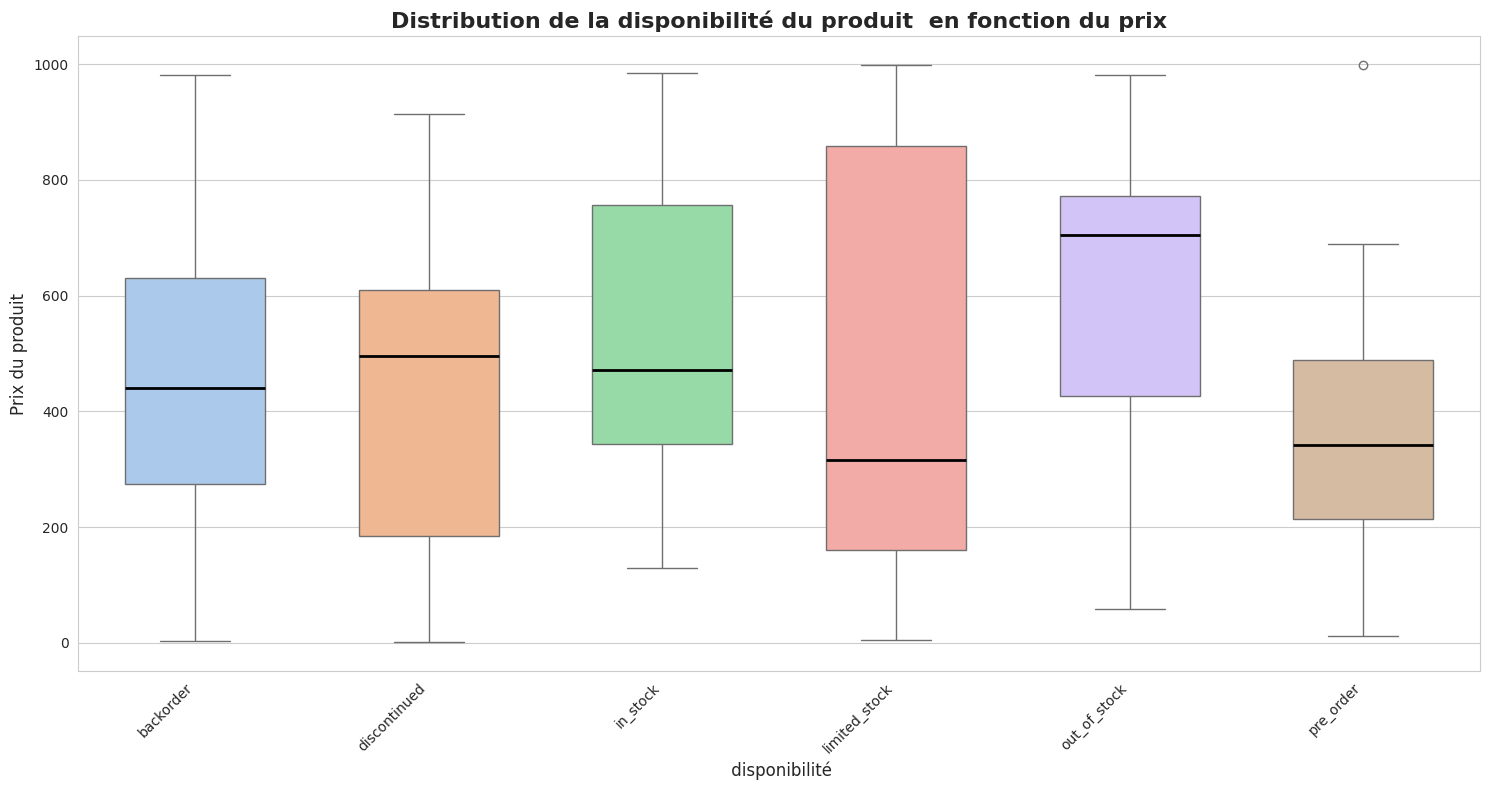

In [ ]:

# 1. Appliquer un style Seaborn agréable (optionnel)
sns.set_style("whitegrid")

# 2. Initialiser la figure avec une taille appropriée pour de nombreuses catégories
#    Largeur adaptée pour les étiquettes, hauteur standard
plt.figure(figsize=(15, 8))

# 3. Tracer le boxplot principal avec des ajustements visuels
sns.boxplot(
    x='Availability',
    y='Price',
    data=df,
    width=0.6,          # Réduit légèrement la largeur des boîtes
    palette="pastel",    # Change la palette de couleurs
    medianprops={'color': 'black', 'linewidth': 2} # Met en évidence la médiane
)

# 4. Améliorer la lisibilité de l'axe X (obligatoire si condensé)
plt.xticks(
    rotation=45,        # Pivote les étiquettes de 45 degrés
    ha='right',         # Alignement horizontal pour mieux coller à la graduation
    fontsize=10         # Ajuste la taille de la police
)

# 5. Ajouter des titres clairs
plt.title("Distribution de la disponibilité du produit  en fonction du prix", fontsize=16, fontweight='bold')
plt.xlabel(" disponibilité", fontsize=12)
plt.ylabel("Prix du produit", fontsize=12)
# 6. Assurer que tout le texte rentre dans la figure
plt.tight_layout()
plt.show()


# Analyse

> Les produit en stock limité ,en stockmet celles en ba
ckorder coûtent relativement plus cheres tandis que les pro
duit aui sont en précommande ou en rupture de stock representent ceux qui valent moins chères


/tmp/ipython-input-3579311799.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


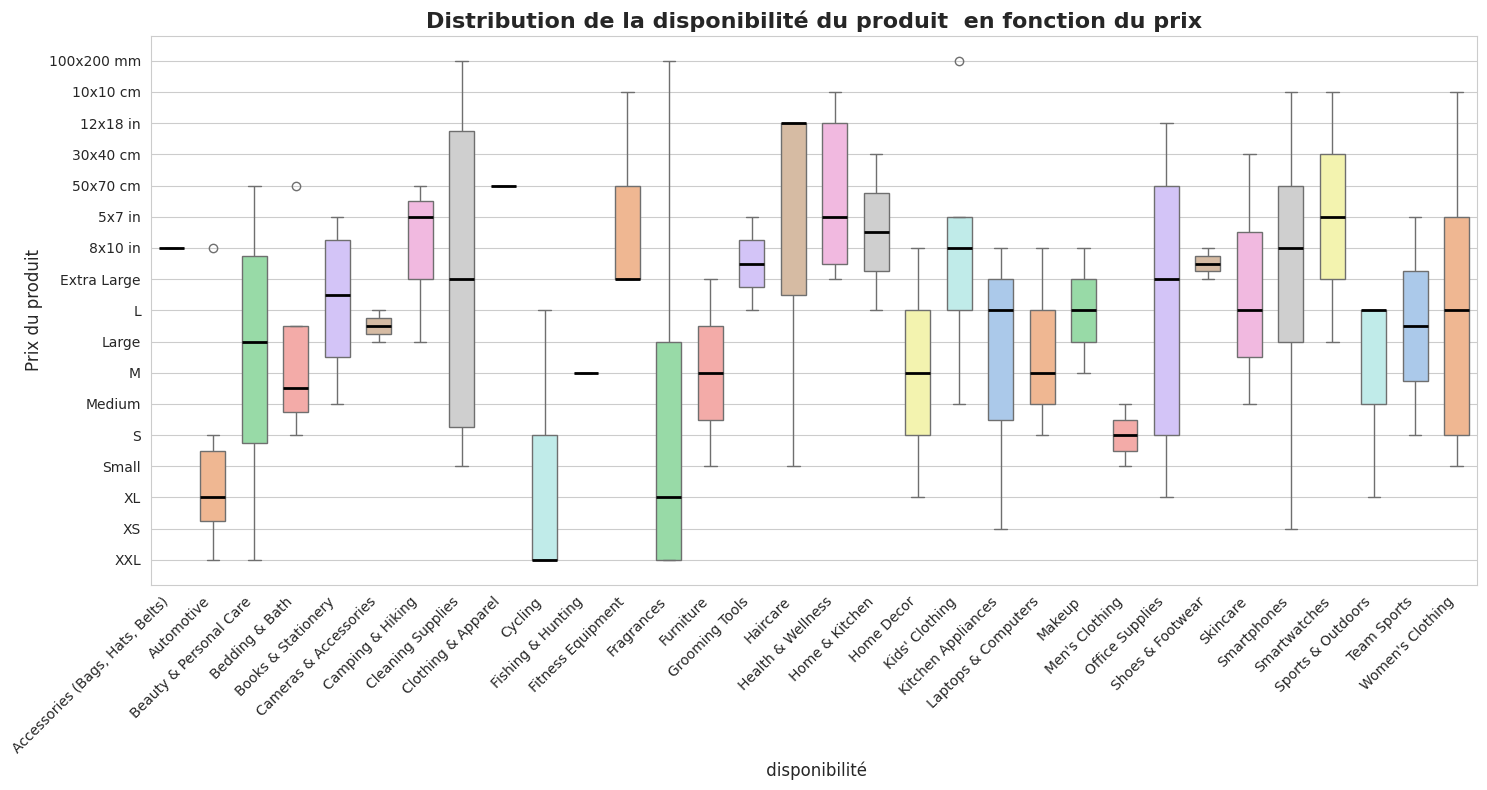

In [ ]:

# 1. Appliquer un style Seaborn agréable (optionnel)
sns.set_style("whitegrid")

# 2. Initialiser la figure avec une taille appropriée pour de nombreuses catégories
#    Largeur adaptée pour les étiquettes, hauteur standard
plt.figure(figsize=(15, 8))

# 3. Tracer le boxplot principal avec des ajustements visuels
sns.boxplot(
    x='Category',
    y='Size',
    data=df,
    width=0.6,          # Réduit légèrement la largeur des boîtes
    palette="pastel",    # Change la palette de couleurs
    medianprops={'color': 'black', 'linewidth': 2} # Met en évidence la médiane
)

# 4. Améliorer la lisibilité de l'axe X (obligatoire si condensé)
plt.xticks(
    rotation=45,        # Pivote les étiquettes de 45 degrés
    ha='right',         # Alignement horizontal pour mieux coller à la graduation
    fontsize=10         # Ajuste la taille de la police
)

# 5. Ajouter des titres clairs
plt.title("Distribution de la catégorie   en fonction de la taille", fontsize=16, fontweight='bold')
plt.xlabel(" disponibilité", fontsize=12)
plt.ylabel("Prix du produit", fontsize=12)
# 6. Assurer que tout le texte rentre dans la figure
plt.tight_layout()
plt.show()


/tmp/ipython-input-412217964.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


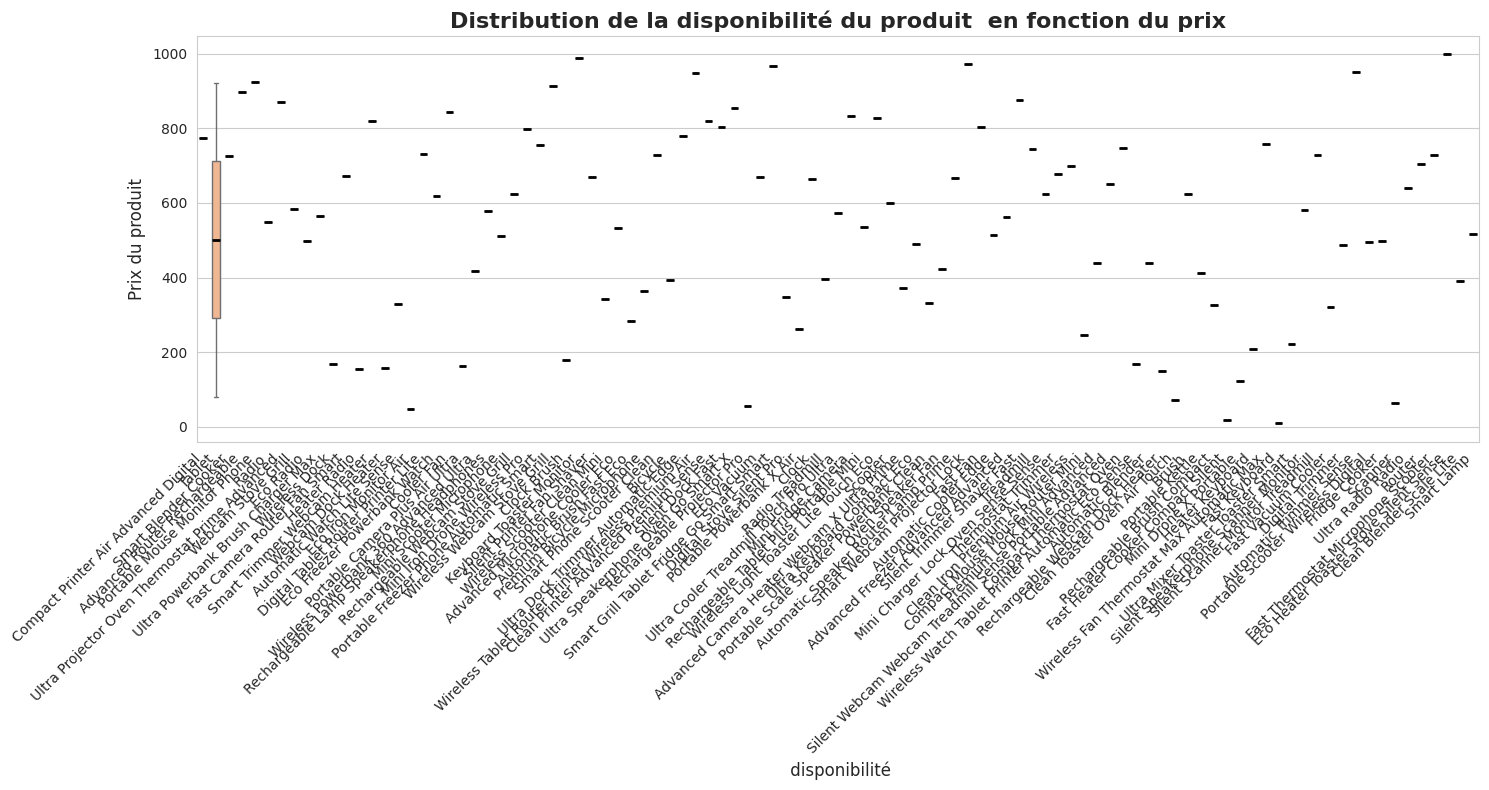

In [ ]:

# 1. Appliquer un style Seaborn agréable (optionnel)
sns.set_style("whitegrid")

# 2. Initialiser la figure avec une taille appropriée pour de nombreuses catégories
#    Largeur adaptée pour les étiquettes, hauteur standard
plt.figure(figsize=(15, 8))

# 3. Tracer le boxplot principal avec des ajustements visuels
sns.boxplot(
    x='Name',
    y='Stock',
    data=df,
    width=0.6,          # Réduit légèrement la largeur des boîtes
    palette="pastel",    # Change la palette de couleurs
    medianprops={'color': 'black', 'linewidth': 2} # Met en évidence la médiane
)

# 4. Améliorer la lisibilité de l'axe X (obligatoire si condensé)
plt.xticks(
    rotation=45,        # Pivote les étiquettes de 45 degrés
    ha='right',         # Alignement horizontal pour mieux coller à la graduation
    fontsize=10         # Ajuste la taille de la police
)

# 5. Ajouter des titres clairs
plt.title("Distribution de la disponibilité du produit  en fonction du prix", fontsize=16, fontweight='bold')
plt.xlabel(" disponibilité", fontsize=12)
plt.ylabel("Prix du produit", fontsize=12)
# 6. Assurer que tout le texte rentre dans la figure
plt.tight_layout()
plt.show()


# Analyse Multivariée

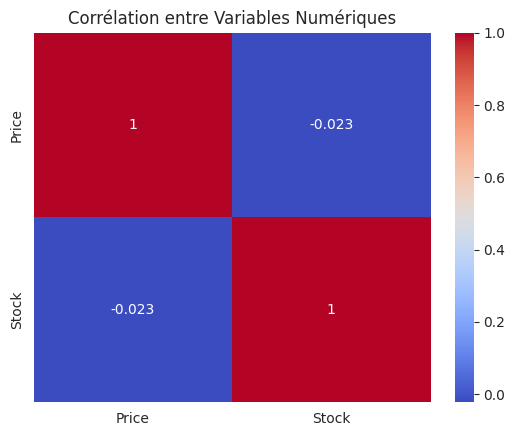

In [ ]:
num_vars=df.select_dtypes('int').columns
corr_matrix = df[num_vars].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Corrélation entre Variables Numériques')
plt.show()

D'apres cette matrice de corelation le prix du produit et sa quantité en stock n'ont aucun lien entre eux ce qui ne semble pas trop proche de ce que l'on oberve souvent